# Inteligencia de Negocios
## Componente Práctico Semana 3 – Modelo Estrella, Visualizaciones y Carga ETL
## Grupo # 3

### ALEJANDRA BEATRIZ TELLO GONZÁLEZ
### PABLO RAMIRO VALLEJO ZÚÑIGA

---

## Introducción

En esta tercera semana se integra el **Modelo de Estrella** (*Star Schema*) que estructura la analítica del proyecto de Ciberseguridad Bancaria sobre la nube.

El proceso sigue el flujo completo del ETL:

| Semana | Fase | Descripción |
|--------|------|-------------|
| 1 | **Extract** | Extracción desde PostgreSQL, CSV y JSON |
| 2 | **Transform** | Limpieza, normalización y correlación de las tres fuentes |
| 3 | **Load** | Modelo Estrella → Visualizaciones → Carga en AWS Redshift |

Las tareas de esta semana son:
1. Función reutilizable para crear dimensiones
2. Tabla de hechos principal del modelo
3. Dimensiones del modelo de estrella
4. Tres visualizaciones de datos
5. Carga final en Amazon Redshift (a cargo de Pablo Ramiro Vallejo Zúñiga)
6. Reflexión individual sobre aplicación laboral


---
## 1. Importación de librerías

Se importan todas las dependencias necesarias para reproducir el pipeline completo de extracción, transformación y carga, incluyendo las librerías de visualización y conexión a AWS.


In [1]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv()
print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


---
## 2. Configuración de conexión y extracción de datos

Se reproduce el pipeline de extracción de la Semana 1 para disponer de los DataFrames base sobre los cuales se aplicará el modelo dimensional.
Las credenciales se gestionan mediante variables de entorno (`.env`) siguiendo los estándares de seguridad PCI-DSS.


In [3]:
# ── Credenciales desde .env ────────────────────────────────────────────────
DB_USER     = os.getenv("POSTGRES_USER")
DB_PASSWORD = os.getenv("POSTGRES_PASSWORD")
DB_NAME     = os.getenv("POSTGRES_DB")
DB_HOST     = os.getenv("POSTGRES_HOST")
DB_PORT     = os.getenv("POSTGRES_PORT", "5432")

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)
print(f"🔌 Conectando a: {DB_HOST}:{DB_PORT}/{DB_NAME} como usuario '{DB_USER}'")


🔌 Conectando a: localhost:5432/dbmcib12b como usuario 'admin'


In [4]:
# ── Extracción de las tres fuentes ────────────────────────────────────────
df_pg   = pd.read_sql("SELECT * FROM api_security_events", engine)
df_csv  = pd.read_csv("data/incidentes_seguridad.csv")
with open("data/vulnerabilidades_cve.json", "r", encoding="utf-8") as f:
    df_json = pd.DataFrame(json.load(f))

print("Fuentes cargadas:")
print(f"  df_pg   : {df_pg.shape[0]} filas × {df_pg.shape[1]} columnas")
print(f"  df_csv  : {df_csv.shape[0]} filas × {df_csv.shape[1]} columnas")
print(f"  df_json : {df_json.shape[0]} filas × {df_json.shape[1]} columnas")


Fuentes cargadas:
  df_pg   : 150 filas × 12 columnas
  df_csv  : 300 filas × 14 columnas
  df_json : 80 filas × 13 columnas


---
## 3. Reproducción de la fase Transform (Semana 2)

Se reproducen las funciones de limpieza y transformación definidas en la Semana 2 para obtener los DataFrames depurados: `df_pg_sel`, `df_csv_real` y `df_json_sel`.
Estos son el insumo directo para construir el modelo dimensional.


In [5]:
# ── Limpieza: API Security Events ──────────────────────────────────────────
def limpiar_api_events(df):
    df = df.copy()
    df["event_date"]   = pd.to_datetime(df["event_date"])
    df["user_agent"]   = df["user_agent"].fillna("Unknown/Automated")
    df["channel"]      = df["channel"].str.strip().str.title()
    df["event_type"]   = df["event_type"].str.strip().str.title()
    df["http_method"]  = df["http_method"].str.strip().str.upper()
    df["country_code"] = df["country_code"].str.strip().str.upper()
    df = df.drop_duplicates()
    df["resolved"] = df["resolved"].astype(bool)
    return df

# ── Limpieza: Incidentes CSV ────────────────────────────────────────────────
def limpiar_incidentes(df):
    df = df.copy()
    df["timestamp"]         = pd.to_datetime(df["timestamp"])
    df["analyst_assigned"]  = df["analyst_assigned"].fillna("Sistema Automatico")
    df["attack_type"]       = df["attack_type"].str.strip().str.title()
    df["severity"]          = df["severity"].str.strip().str.title()
    df["protocol"]          = df["protocol"].str.strip().str.upper()
    df["status"]            = df["status"].str.strip().str.title()
    df["affected_system"]   = df["affected_system"].str.strip().str.title()
    df = df.drop_duplicates()
    df["false_positive"] = df["false_positive"].astype(bool)
    return df

# ── Limpieza: Vulnerabilidades CVE ─────────────────────────────────────────
def limpiar_vulnerabilidades(df):
    df = df.copy()
    df["discovery_date"]     = pd.to_datetime(df["discovery_date"])
    df["patch_applied"]      = df["patch_applied"].fillna(False).astype(bool)
    df["cvss_severity"]      = df["cvss_severity"].str.strip().str.title()
    df["vulnerability_type"] = df["vulnerability_type"].str.strip().str.title()
    df["system"]             = df["system"].str.strip()
    df["vendor"]             = df["vendor"].str.strip()
    df = df.drop_duplicates()
    df["cvss_score"] = df["cvss_score"].round(1)
    return df

df_pg_clean   = limpiar_api_events(df_pg)
df_csv_clean  = limpiar_incidentes(df_csv)
df_json_clean = limpiar_vulnerabilidades(df_json)
print("✅ Limpieza completada")


✅ Limpieza completada


In [6]:
# ── Selección de columnas ──────────────────────────────────────────────────
cols_pg = ["event_id","event_date","channel","event_type","http_method",
           "endpoint","response_code","response_time_ms","risk_score",
           "resolved","country_code"]
df_pg_sel = df_pg_clean[cols_pg].copy()

cols_csv = ["incident_id","timestamp","attack_type","protocol","destination_port",
            "packets_sent","bytes_transferred","duration_seconds","severity",
            "status","affected_system","analyst_assigned","false_positive"]
df_csv_sel = df_csv_clean[cols_csv].copy()

cols_json = ["vuln_id","cve_id","system","vendor","vulnerability_type","cvss_score",
             "cvss_severity","patch_available","patch_applied","discovery_date",
             "remediation_deadline_days","affected_hosts","exploited_in_wild"]
df_json_sel = df_json_clean[cols_json].copy()

# ── Transformaciones ────────────────────────────────────────────────────────
risk_to_severity = {1: "Low", 2: "Low", 3: "Medium", 4: "High", 5: "Critical"}
df_pg_sel["risk_category"]  = df_pg_sel["risk_score"].apply(
    lambda x: "Crítico" if x == 5 else "Alto" if x == 4 else "Medio" if x == 3 else "Bajo")
df_pg_sel["respuesta_lenta"] = df_pg_sel["response_time_ms"] > 2000
df_pg_sel["mes_evento"]      = df_pg_sel["event_date"].dt.to_period("M").astype(str)
df_pg_sel["es_error_http"]   = df_pg_sel["response_code"] >= 400
df_pg_sel["severity_std"]    = df_pg_sel["risk_score"].map(risk_to_severity)

severity_map = {"Low": 1, "Medium": 2, "High": 3, "Critical": 4}
df_csv_sel["severity_nivel"]    = df_csv_sel["severity"].map(severity_map)
df_csv_sel["duration_minutes"]  = (df_csv_sel["duration_seconds"] / 60).round(2)
df_csv_sel["volumen_trafico"]   = df_csv_sel["bytes_transferred"].apply(
    lambda x: "Alto" if x > 5_000_000 else "Medio" if x > 500_000 else "Bajo")
df_csv_sel["mes_incidente"]     = df_csv_sel["timestamp"].dt.to_period("M").astype(str)
df_csv_sel["severity_std"]      = df_csv_sel["severity"].str.title()
df_csv_real = df_csv_sel[df_csv_sel["false_positive"] == False].copy()

def calcular_prioridad(row):
    if row["exploited_in_wild"] and row["cvss_score"] >= 7:
        return "Inmediata"
    elif row["cvss_score"] >= 9:
        return "Urgente"
    elif row["cvss_score"] >= 7:
        return "Alta"
    elif row["cvss_score"] >= 4:
        return "Media"
    else:
        return "Baja"

df_json_sel["prioridad_remediacion"]      = df_json_sel.apply(calcular_prioridad, axis=1)
df_json_sel["dias_desde_descubrimiento"]  = (pd.Timestamp("today") - df_json_sel["discovery_date"]).dt.days
df_json_sel["estado_parche"]              = df_json_sel.apply(
    lambda r: "Aplicado" if r["patch_applied"] else ("Disponible" if r["patch_available"] else "Sin parche"), axis=1)
df_json_sel["severity_std"] = df_json_sel["cvss_severity"].str.title()

# IDs ETL
df_pg_sel   = df_pg_sel.reset_index(drop=True);   df_pg_sel["etl_id_evento"]     = df_pg_sel.index + 1
df_csv_real = df_csv_real.reset_index(drop=True); df_csv_real["etl_id_incidente"] = df_csv_real.index + 1
df_json_sel = df_json_sel.reset_index(drop=True); df_json_sel["etl_id_vuln"]     = df_json_sel.index + 1

print("✅ Transformaciones y IDs ETL aplicados")
print(f"   df_pg_sel   : {df_pg_sel.shape}")
print(f"   df_csv_real : {df_csv_real.shape}")
print(f"   df_json_sel : {df_json_sel.shape}")


✅ Transformaciones y IDs ETL aplicados
   df_pg_sel   : (150, 17)
   df_csv_real : (251, 19)
   df_json_sel : (80, 18)


---
## 4. Modelo de Estrella – Star Schema

El modelo de estrella organiza los datos en una **tabla de hechos central** rodeada de **tablas de dimensión**.  
Para el dominio de Ciberseguridad Bancaria se define la siguiente arquitectura:

```
                    DIM_TIEMPO
                        │
DIM_CANAL ──── FACT_SEGURIDAD_BANCARIA ──── DIM_SEVERIDAD
                        │
                 DIM_VULNERABILIDAD
```

| Tabla | Tipo | Descripción |
|-------|------|-------------|
| `FACT_SEGURIDAD_BANCARIA` | Hechos | Métricas consolidadas por severidad y canal |
| `DIM_TIEMPO` | Dimensión | Período mensual de los eventos |
| `DIM_CANAL` | Dimensión | Canales bancarios digitales |
| `DIM_SEVERIDAD` | Dimensión | Niveles Low / Medium / High / Critical |
| `DIM_VULNERABILIDAD` | Dimensión | CVEs con estado de parche y prioridad |

### ¿Por qué Star Schema y no Snowflake?

En el sector bancario, el **Star Schema** es preferible para reportes operativos porque:
- Las consultas son más simples (menos JOINs), reduciendo latencia en dashboards de SOC
- Compatible con herramientas BI como Tableau, Power BI y Amazon QuickSight sin transformaciones adicionales
- Cumple con los requerimientos de trazabilidad de la Superintendencia de Bancos para auditorías


---
## 5. Función para crear dimensiones

Se define una función genérica y reutilizable `crear_dimension` que recibe cualquier DataFrame,  
selecciona las columnas relevantes, elimina duplicados y genera una **clave subrogada** (`sk_`) secuencial.  
Esta función puede aplicarse a cualquier dimensión del modelo sin modificar su lógica interna.


In [7]:
def crear_dimension(df: pd.DataFrame, columnas: list, nombre_sk: str,
                    col_dedup: str = None) -> pd.DataFrame:
    """
    Crea una tabla de dimensión a partir de un DataFrame fuente.

    Parámetros:
    -----------
    df         : DataFrame fuente con los datos originales.
    columnas   : Lista de columnas a incluir en la dimensión.
    nombre_sk  : Nombre de la clave subrogada (surrogate key) a generar.
    col_dedup  : Columna de deduplicación; si es None, se deduplicará sobre todas.

    Retorna:
    --------
    DataFrame de dimensión con clave subrogada secuencial en la primera posición.

    Diseño:
    -------
    - La clave subrogada es independiente de las claves naturales del sistema fuente,
      lo que permite manejar cambios SCD (Slowly Changing Dimensions) sin romper las
      referencias de la tabla de hechos.
    - En entornos bancarios regulados, las SKs facilitan la trazabilidad de datos entre
      versiones de carga sin alterar los IDs de los sistemas transaccionales.
    """
    dim = df[columnas].copy()

    # Deduplicar por columna específica o por todas las columnas
    if col_dedup:
        dim = dim.drop_duplicates(subset=[col_dedup]).reset_index(drop=True)
    else:
        dim = dim.drop_duplicates().reset_index(drop=True)

    # Generar clave subrogada secuencial (base 1)
    dim.insert(0, nombre_sk, range(1, len(dim) + 1))

    return dim

print("✅ Función crear_dimension definida correctamente")
print()
print("Firma: crear_dimension(df, columnas, nombre_sk, col_dedup=None)")
print("Retorna: DataFrame con SK secuencial + columnas seleccionadas, sin duplicados")


✅ Función crear_dimension definida correctamente

Firma: crear_dimension(df, columnas, nombre_sk, col_dedup=None)
Retorna: DataFrame con SK secuencial + columnas seleccionadas, sin duplicados


---
## 6. Creación de Dimensiones

Se crean las cuatro dimensiones del modelo de estrella usando la función `crear_dimension`.  
Cada dimensión tiene su propia clave subrogada (`sk_`) que será referenciada por la tabla de hechos.


### 6.1 DIM_TIEMPO

Captura el período mensual de los eventos para permitir análisis temporales en el DW.  
La granularidad mensual es estándar en reportes de seguridad bancaria (SLA de incidentes, métricas MTTR mensual).


In [8]:
# ── DIM_TIEMPO ──────────────────────────────────────────────────────────────
# Se obtienen todos los períodos únicos de las tres fuentes
meses_eventos     = df_pg_sel[["mes_evento"]].rename(columns={"mes_evento": "periodo"})
meses_incidentes  = df_csv_real[["mes_incidente"]].rename(columns={"mes_incidente": "periodo"})
meses_vulns       = df_json_sel[["discovery_date"]].assign(
    periodo=df_json_sel["discovery_date"].dt.to_period("M").astype(str)
)[["periodo"]]

df_periodos = pd.concat([meses_eventos, meses_incidentes, meses_vulns], ignore_index=True)
df_periodos["anio"] = df_periodos["periodo"].str[:4].astype(int)
df_periodos["mes"]  = df_periodos["periodo"].str[5:].astype(int)
df_periodos["trimestre"] = ((df_periodos["mes"] - 1) // 3 + 1).apply(lambda q: f"Q{q}")

dim_tiempo = crear_dimension(
    df       = df_periodos,
    columnas = ["periodo", "anio", "mes", "trimestre"],
    nombre_sk= "sk_tiempo",
    col_dedup= "periodo"
).sort_values("sk_tiempo").reset_index(drop=True)

print("══ DIM_TIEMPO ══")
print(f"Shape: {dim_tiempo.shape}")
print(dim_tiempo.to_string(index=False))


══ DIM_TIEMPO ══
Shape: (12, 5)
 sk_tiempo periodo  anio  mes trimestre
         1 2024-01  2024    1        Q1
         2 2024-02  2024    2        Q1
         3 2024-03  2024    3        Q1
         4 2024-04  2024    4        Q2
         5 2024-05  2024    5        Q2
         6 2024-06  2024    6        Q2
         7 2024-07  2024    7        Q3
         8 2024-08  2024    8        Q3
         9 2024-09  2024    9        Q3
        10 2024-10  2024   10        Q4
        11 2024-12  2024   12        Q4
        12 2024-11  2024   11        Q4


### 6.2 DIM_CANAL

Dimensión de los canales bancarios digitales desde los cuales se registran eventos de seguridad.  
Clave para reportes regulatorios: la Superintendencia de Bancos exige controles diferenciados por canal.


In [9]:
# ── DIM_CANAL ────────────────────────────────────────────────────────────────
df_canales = df_pg_sel[["channel"]].copy()

# Clasificar tipo de canal para análisis adicional
def tipo_canal(canal):
    canal_l = canal.lower()
    if "mobile" in canal_l:
        return "Móvil"
    elif "internet" in canal_l or "web" in canal_l:
        return "Web"
    elif "cash" in canal_l or "management" in canal_l:
        return "Corporativo"
    elif "atm" in canal_l:
        return "Autoservicio"
    else:
        return "Otro"

df_canales["tipo_canal"] = df_canales["channel"].apply(tipo_canal)

dim_canal = crear_dimension(
    df       = df_canales,
    columnas = ["channel", "tipo_canal"],
    nombre_sk= "sk_canal",
    col_dedup= "channel"
).sort_values("sk_canal").reset_index(drop=True)

print("══ DIM_CANAL ══")
print(f"Shape: {dim_canal.shape}")
print(dim_canal.to_string(index=False))


══ DIM_CANAL ══
Shape: (6, 3)
 sk_canal          channel   tipo_canal
        1 Internet Banking          Web
        2  Cash Management  Corporativo
        3     Pos Terminal         Otro
        4   Mobile Banking        Móvil
        5      Atm Network Autoservicio
        6 Open Banking Api         Otro


### 6.3 DIM_SEVERIDAD

Dimensión que unifica los niveles de severidad de las tres fuentes.  
Es la dimensión puente que permite correlacionar eventos, incidentes y vulnerabilidades bajo un criterio común.


In [10]:
# ── DIM_SEVERIDAD ────────────────────────────────────────────────────────────
severidades_unicas = pd.DataFrame({
    "severity_std" : ["Low", "Medium", "High", "Critical"],
    "nivel_numerico": [1, 2, 3, 4],
    "descripcion"  : [
        "Riesgo bajo — monitoreo rutinario",
        "Riesgo medio — revisión en 72h",
        "Riesgo alto — atención prioritaria en 24h",
        "Riesgo crítico — respuesta inmediata < 4h"
    ],
    "color_semaforo": ["Verde", "Amarillo", "Naranja", "Rojo"]
})

dim_severidad = crear_dimension(
    df       = severidades_unicas,
    columnas = ["severity_std", "nivel_numerico", "descripcion", "color_semaforo"],
    nombre_sk= "sk_severidad",
    col_dedup= "severity_std"
)

print("══ DIM_SEVERIDAD ══")
print(f"Shape: {dim_severidad.shape}")
print(dim_severidad.to_string(index=False))


══ DIM_SEVERIDAD ══
Shape: (4, 5)
 sk_severidad severity_std  nivel_numerico                               descripcion color_semaforo
            1          Low               1         Riesgo bajo — monitoreo rutinario          Verde
            2       Medium               2            Riesgo medio — revisión en 72h       Amarillo
            3         High               3 Riesgo alto — atención prioritaria en 24h        Naranja
            4     Critical               4 Riesgo crítico — respuesta inmediata < 4h           Rojo


### 6.4 DIM_VULNERABILIDAD

Dimensión de las vulnerabilidades CVE identificadas en los escaneos de infraestructura.  
En el sector bancario, el estado del parche y la prioridad de remediación son KPIs auditados por la SB.


In [11]:
# ── DIM_VULNERABILIDAD ───────────────────────────────────────────────────────
cols_vuln_dim = ["vuln_id", "cve_id", "system", "vendor", "vulnerability_type",
                 "cvss_score", "cvss_severity", "estado_parche",
                 "prioridad_remediacion", "dias_desde_descubrimiento",
                 "affected_hosts", "exploited_in_wild"]

dim_vulnerabilidad = crear_dimension(
    df       = df_json_sel,
    columnas = cols_vuln_dim,
    nombre_sk= "sk_vuln",
    col_dedup= "vuln_id"
).sort_values("sk_vuln").reset_index(drop=True)

print("══ DIM_VULNERABILIDAD ══")
print(f"Shape: {dim_vulnerabilidad.shape}")
print(dim_vulnerabilidad.head(5).to_string(index=False))
print(f"  ... ({len(dim_vulnerabilidad)} registros totales)")


══ DIM_VULNERABILIDAD ══
Shape: (80, 13)
 sk_vuln  vuln_id         cve_id     system                      vendor     vulnerability_type  cvss_score cvss_severity estado_parche prioridad_remediacion  dias_desde_descubrimiento  affected_hosts  exploited_in_wild
       1        1 CVE-2024-29772 Apache 2.4           Apache Foundation      Denial Of Service         5.2        Medium      Aplicado                 Media                        653               6              False
       2        2 CVE-2024-19156 Python 3.8 PostgreSQL Global Dev Group        Buffer Overflow         3.9           Low      Aplicado                  Baja                        611               4              False
       3        3 CVE-2023-82963 nginx 1.18 PostgreSQL Global Dev Group  Remote Code Execution         8.9          High      Aplicado             Inmediata                        854              24               True
       4        4 CVE-2022-18229 Python 3.8             OpenSSL Project Information

---
## 7. Tabla de Hechos – FACT_SEGURIDAD_BANCARIA

La tabla de hechos es el **núcleo del modelo estrella**. Contiene las métricas numéricas del negocio  
y las claves foráneas (FKs) que referencian a cada dimensión.

### Claves foráneas (FKs)
| FK | Dimensión referenciada |
|----|------------------------|
| `fk_tiempo` | DIM_TIEMPO |
| `fk_canal` | DIM_CANAL |
| `fk_severidad` | DIM_SEVERIDAD |

### Métricas (hechos)
| Métrica | Descripción |
|---------|-------------|
| `total_eventos_api` | Eventos de seguridad en APIs bancarias |
| `total_incidentes` | Incidentes de red detectados por el SOC |
| `total_vulnerabilidades` | CVEs identificados |
| `resp_time_promedio_ms` | Latencia promedio de APIs (KPI de disponibilidad) |
| `bytes_promedio_incidente` | Volumen de datos por incidente (indicador de exfiltración) |
| `cvss_score_promedio` | Score CVSS promedio de vulnerabilidades |
| `eventos_no_resueltos` | Eventos pendientes de cierre |
| `incidentes_criticos` | Incidentes con severity_std = Critical |
| `vulns_sin_parche` | Vulnerabilidades sin parche aplicado |
| `hosts_afectados_total` | Total de hosts impactados por CVEs |


In [12]:
# ── Agregación por severidad + canal + período ─────────────────────────────

# Métricas desde PostgreSQL
agg_pg = (
    df_pg_sel.groupby(["severity_std", "channel", "mes_evento"])
    .agg(
        total_eventos_api     = ("event_id", "count"),
        resp_time_promedio_ms = ("response_time_ms", "mean"),
        eventos_no_resueltos  = ("resolved", lambda x: (~x).sum())
    )
    .reset_index()
    .rename(columns={"mes_evento": "periodo"})
)
agg_pg["resp_time_promedio_ms"] = agg_pg["resp_time_promedio_ms"].round(1)

# Métricas desde CSV (agrupado por severidad + mes; canal no aplica en CSV)
agg_csv = (
    df_csv_real.groupby(["severity_std", "mes_incidente"])
    .agg(
        total_incidentes        = ("incident_id", "count"),
        bytes_promedio_incidente= ("bytes_transferred", "mean"),
        incidentes_criticos     = ("severity", lambda x: (x == "Critical").sum())
    )
    .reset_index()
    .rename(columns={"mes_incidente": "periodo"})
)
agg_csv["bytes_promedio_incidente"] = agg_csv["bytes_promedio_incidente"].round(0).astype(int)

# Métricas desde JSON (agrupado por cvss_severity)
agg_json = (
    df_json_sel.groupby("severity_std")
    .agg(
        total_vulnerabilidades = ("vuln_id", "count"),
        cvss_score_promedio    = ("cvss_score", "mean"),
        hosts_afectados_total  = ("affected_hosts", "sum"),
        vulns_sin_parche       = ("patch_applied", lambda x: (~x).sum())
    )
    .reset_index()
)
agg_json["cvss_score_promedio"] = agg_json["cvss_score_promedio"].round(2)

print(f"agg_pg   : {agg_pg.shape}")
print(f"agg_csv  : {agg_csv.shape}")
print(f"agg_json : {agg_json.shape}")


agg_pg   : (108, 6)
agg_csv  : (20, 5)
agg_json : (4, 5)


In [13]:
# ── Construcción de la tabla de hechos ────────────────────────────────────
fact = (
    agg_pg
    .merge(agg_csv,  on=["severity_std", "periodo"], how="outer")
    .merge(agg_json, on="severity_std",              how="left")
)

# Rellenar nulos en métricas con 0 (ausencia de registros en ese cruce)
metricas = ["total_eventos_api","resp_time_promedio_ms","eventos_no_resueltos",
            "total_incidentes","bytes_promedio_incidente","incidentes_criticos",
            "total_vulnerabilidades","cvss_score_promedio",
            "hosts_afectados_total","vulns_sin_parche"]
fact[metricas] = fact[metricas].fillna(0)

# ── Unir las FKs de las dimensiones ──────────────────────────────────────
fact = (
    fact
    .merge(dim_severidad[["sk_severidad","severity_std"]], on="severity_std", how="left")
    .merge(dim_canal[["sk_canal","channel"]],             on="channel",       how="left")
    .merge(dim_tiempo[["sk_tiempo","periodo"]],            on="periodo",       how="left")
)

# ── Renombrar FKs ─────────────────────────────────────────────────────────
fact = fact.rename(columns={
    "sk_severidad": "fk_severidad",
    "sk_canal"    : "fk_canal",
    "sk_tiempo"   : "fk_tiempo"
})

# ── Generar SK de la tabla de hechos ──────────────────────────────────────
fact = fact.reset_index(drop=True)
fact.insert(0, "sk_fact", fact.index + 1)

# ── Ordenar columnas: SK → FKs → métricas ────────────────────────────────
cols_fact = (
    ["sk_fact", "fk_severidad", "fk_canal", "fk_tiempo",
     "severity_std", "channel", "periodo"]
    + metricas
)
# Incluir solo columnas existentes
cols_fact = [c for c in cols_fact if c in fact.columns]
fact_final = fact[cols_fact].copy()

print("══ FACT_SEGURIDAD_BANCARIA ══")
print(f"Shape: {fact_final.shape}")
print(f"Filas  : {len(fact_final)} combinaciones (severidad × canal × período)")
print(f"Columnas: {list(fact_final.columns)}")
print()
print(fact_final.head(5).to_string(index=False))


══ FACT_SEGURIDAD_BANCARIA ══
Shape: (110, 17)
Filas  : 110 combinaciones (severidad × canal × período)
Columnas: ['sk_fact', 'fk_severidad', 'fk_canal', 'fk_tiempo', 'severity_std', 'channel', 'periodo', 'total_eventos_api', 'resp_time_promedio_ms', 'eventos_no_resueltos', 'total_incidentes', 'bytes_promedio_incidente', 'incidentes_criticos', 'total_vulnerabilidades', 'cvss_score_promedio', 'hosts_afectados_total', 'vulns_sin_parche']

 sk_fact  fk_severidad  fk_canal  fk_tiempo severity_std          channel periodo  total_eventos_api  resp_time_promedio_ms  eventos_no_resueltos  total_incidentes  bytes_promedio_incidente  incidentes_criticos  total_vulnerabilidades  cvss_score_promedio  hosts_afectados_total  vulns_sin_parche
       1             4       3.0          1     Critical     Pos Terminal 2024-01                1.0                  779.0                   0.0               4.0                 2465420.0                  4.0                      14                 9.54       

In [14]:
# ── Validación de integridad referencial ──────────────────────────────────
print("══ VALIDACIÓN – Tabla de Hechos ══")
print(f"  SK nulos          : {fact_final['sk_fact'].isnull().sum()}")
print(f"  Filas duplicadas  : {fact_final.duplicated().sum()}")
print(f"  fk_severidad nulos: {fact_final['fk_severidad'].isnull().sum()}")
print(f"  fk_tiempo nulos   : {fact_final['fk_tiempo'].isnull().sum()}")
print()
print("── Resumen de métricas clave ──")
print(fact_final[metricas].describe().round(2).to_string())


══ VALIDACIÓN – Tabla de Hechos ══
  SK nulos          : 0
  Filas duplicadas  : 0
  fk_severidad nulos: 0
  fk_tiempo nulos   : 0

── Resumen de métricas clave ──
       total_eventos_api  resp_time_promedio_ms  eventos_no_resueltos  total_incidentes  bytes_promedio_incidente  incidentes_criticos  total_vulnerabilidades  cvss_score_promedio  hosts_afectados_total  vulns_sin_parche
count             110.00                 110.00                110.00            110.00                    110.00               110.00                  110.00               110.00                 110.00            110.00
mean                1.36                2409.15                  0.51              7.40                2622620.54                 0.20                   22.46                 5.52                 543.13             13.42
std                 0.66                1290.24                  0.63              8.57                2754419.58                 0.85                    6.31               

---
## 8. Visualizaciones de datos

Se crean tres visualizaciones que permiten analizar los datos desde perspectivas complementarias  
para la toma de decisiones en el ámbito de Ciberseguridad Bancaria.

| # | Visualización | Pregunta de negocio |
|---|---------------|---------------------|
| 1 | Distribución de eventos por canal y severidad | ¿Qué canal concentra mayor riesgo? |
| 2 | CVSS promedio vs vulnerabilidades sin parche | ¿Dónde está el mayor riesgo residual? |
| 3 | Incidentes reales vs tiempo de respuesta API | ¿Los ataques impactan la disponibilidad de las APIs? |


### 8.1 Visualización 1 – Eventos de API por Canal y Severidad

**Pregunta de negocio:** ¿Qué canal bancario digital concentra la mayor cantidad de eventos de riesgo alto y crítico?

**Relevancia:** Permite priorizar controles de acceso y monitoreo en los canales más vulnerables,  
alineado con los requerimientos de la Resolución JBPD-2022-002 de la Superintendencia de Bancos del Ecuador.


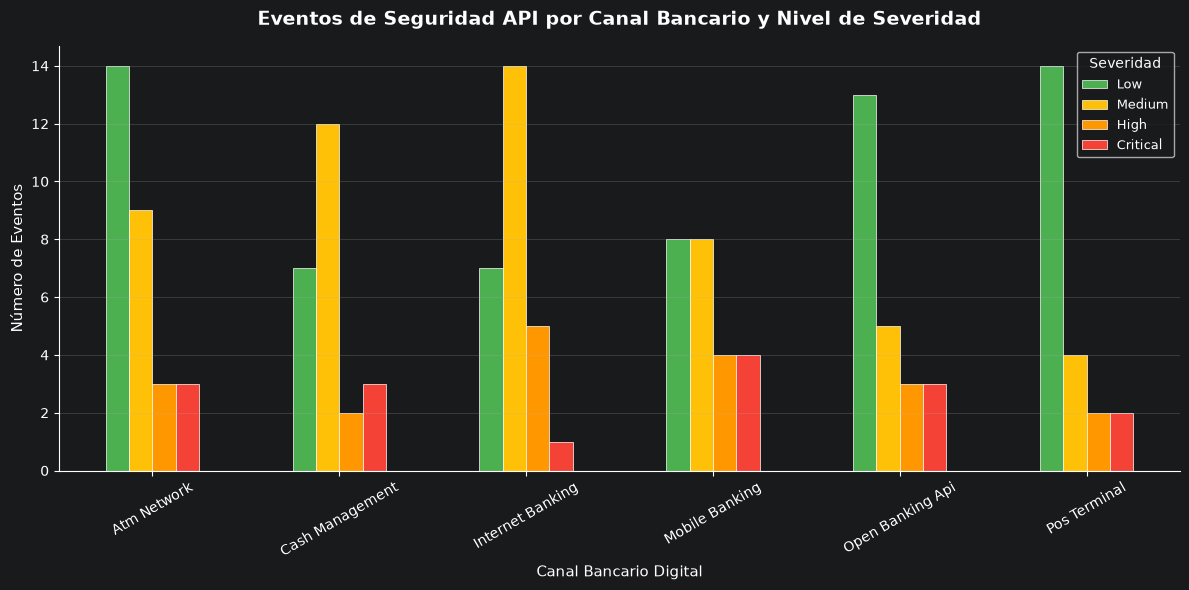

✅ Visualización 1 guardada: viz1_eventos_canal_severidad.png


In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

# Preparar datos: pivot canal × severidad
orden_sev = ["Low", "Medium", "High", "Critical"]
colores   = {"Low": "#4CAF50", "Medium": "#FFC107", "High": "#FF9800", "Critical": "#F44336"}

pivot = (
    df_pg_sel.groupby(["channel", "severity_std"])["event_id"]
    .count()
    .unstack(fill_value=0)
    .reindex(columns=[s for s in orden_sev if s in df_pg_sel["severity_std"].unique()], fill_value=0)
)

pivot.plot(kind="bar", ax=ax, color=[colores[s] for s in pivot.columns],
           edgecolor="white", linewidth=0.5)

ax.set_title("Eventos de Seguridad API por Canal Bancario y Nivel de Severidad",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Canal Bancario Digital", fontsize=11)
ax.set_ylabel("Número de Eventos", fontsize=11)
ax.legend(title="Severidad", title_fontsize=10, fontsize=9,
          labels=[s for s in pivot.columns])
ax.tick_params(axis="x", rotation=30)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis="y", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig("viz1_eventos_canal_severidad.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Visualización 1 guardada: viz1_eventos_canal_severidad.png")


### 8.2 Visualización 2 – Riesgo Residual: CVSS vs Vulnerabilidades sin Parche

**Pregunta de negocio:** ¿Qué nivel de severidad concentra más vulnerabilidades sin parche y con mayor score CVSS?

**Relevancia:** El riesgo residual (CVE sin parche + CVSS alto) es el principal hallazgo en auditorías PCI-DSS.  
Esta visualización permite priorizar el roadmap de patch management del equipo de infraestructura.


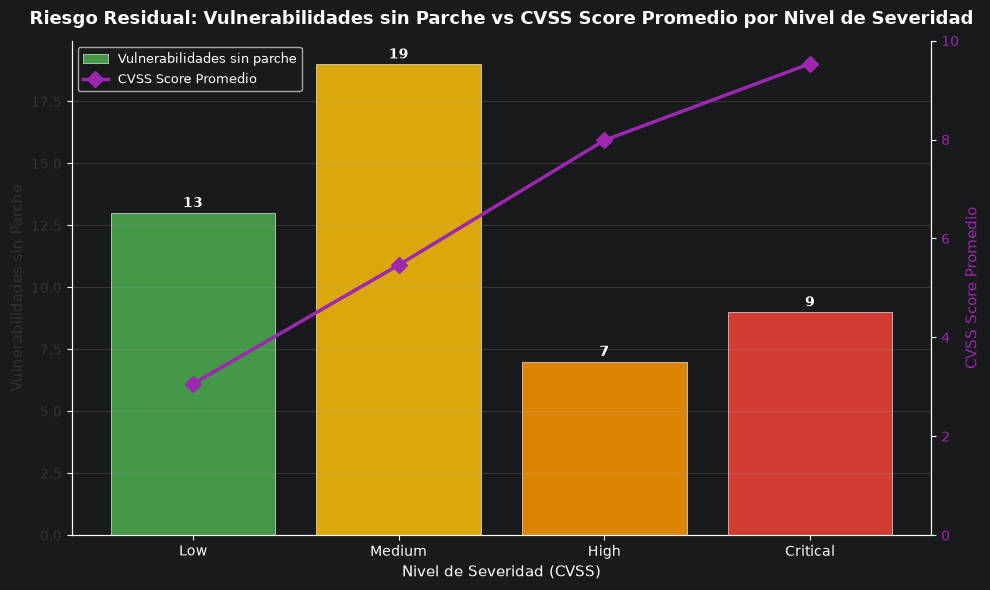

✅ Visualización 2 guardada: viz2_riesgo_residual_cvss.png


In [16]:
fig, ax1 = plt.subplots(figsize=(10, 6))

orden_sev  = ["Low", "Medium", "High", "Critical"]
colores_barra = ["#4CAF50", "#FFC107", "#FF9800", "#F44336"]

sev_agg = (
    df_json_sel.groupby("severity_std")
    .agg(vulns_sin_parche=("patch_applied", lambda x: (~x).sum()),
         cvss_promedio   =("cvss_score", "mean"))
    .reindex(orden_sev)
    .reset_index()
)

bars = ax1.bar(sev_agg["severity_std"], sev_agg["vulns_sin_parche"],
               color=colores_barra, alpha=0.85, edgecolor="white", linewidth=0.5,
               label="Vulnerabilidades sin parche")
ax1.set_xlabel("Nivel de Severidad (CVSS)", fontsize=11)
ax1.set_ylabel("Vulnerabilidades sin Parche", fontsize=11, color="#333333")
ax1.tick_params(axis="y", labelcolor="#333333")

# Eje secundario: CVSS promedio
ax2 = ax1.twinx()
ax2.plot(sev_agg["severity_std"], sev_agg["cvss_promedio"],
         color="#9C27B0", marker="D", linewidth=2.5, markersize=8,
         label="CVSS Score Promedio")
ax2.set_ylabel("CVSS Score Promedio", fontsize=11, color="#9C27B0")
ax2.tick_params(axis="y", labelcolor="#9C27B0")
ax2.set_ylim(0, 10)

# Etiquetas sobre las barras
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
             str(int(bar.get_height())), ha="center", va="bottom", fontsize=10, fontweight="bold")

ax1.set_title("Riesgo Residual: Vulnerabilidades sin Parche vs CVSS Score Promedio por Nivel de Severidad",
              fontsize=13, fontweight="bold", pad=12)

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

ax1.grid(axis="y", alpha=0.3)
sns.despine(right=False)

plt.tight_layout()
plt.savefig("viz2_riesgo_residual_cvss.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Visualización 2 guardada: viz2_riesgo_residual_cvss.png")


### 8.3 Visualización 3 – Incidentes Reales vs Tiempo de Respuesta API por Severidad

**Pregunta de negocio:** ¿Los ataques de alta severidad correlacionan con mayor latencia en las APIs bancarias?

**Relevancia:** Una correlación positiva indicaría que los atacantes están causando degradación del servicio  
(ataques DoS encubiertos). Esta información es clave para configurar umbrales del API Gateway y del WAF.


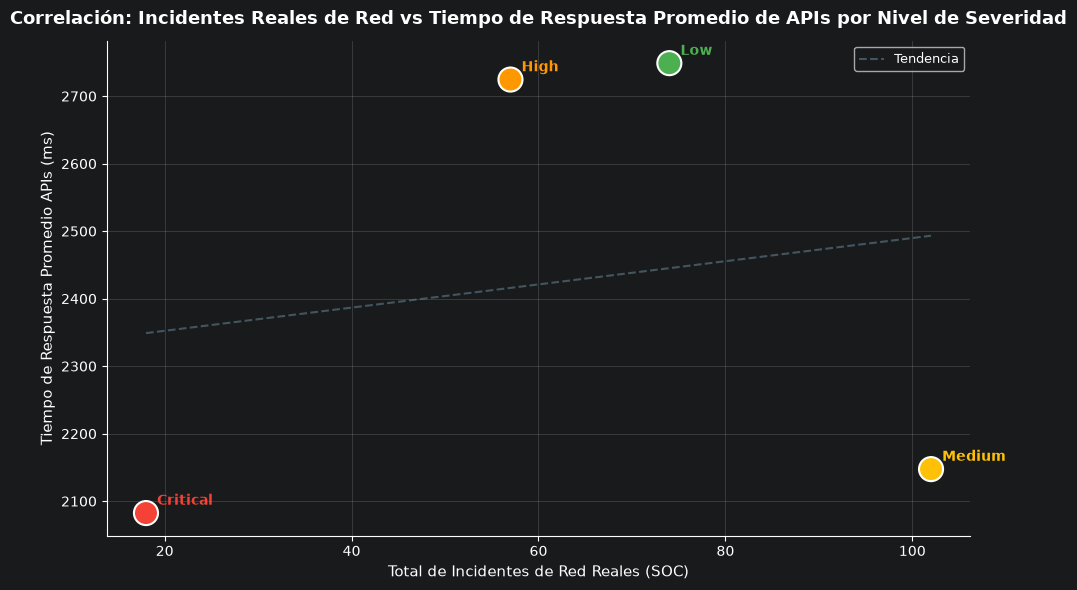

✅ Visualización 3 guardada: viz3_incidentes_vs_latencia.png


In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

orden_sev  = ["Low", "Medium", "High", "Critical"]
colores_s  = {"Low": "#4CAF50", "Medium": "#FFC107", "High": "#FF9800", "Critical": "#F44336"}

# Datos por severidad
incidentes_sev = (df_csv_real.groupby("severity_std")["incident_id"]
                  .count().reindex(orden_sev).reset_index()
                  .rename(columns={"incident_id": "total_incidentes"}))

resp_time_sev = (df_pg_sel.groupby("severity_std")["response_time_ms"]
                 .mean().reindex(orden_sev).reset_index()
                 .rename(columns={"response_time_ms": "resp_time_ms"}))

merged_viz3 = incidentes_sev.merge(resp_time_sev, on="severity_std")

scatter = ax.scatter(
    merged_viz3["total_incidentes"],
    merged_viz3["resp_time_ms"],
    c=[colores_s[s] for s in merged_viz3["severity_std"]],
    s=300, edgecolors="white", linewidths=1.5, zorder=5
)

# Etiquetas de cada punto
for _, row in merged_viz3.iterrows():
    ax.annotate(row["severity_std"],
                xy=(row["total_incidentes"], row["resp_time_ms"]),
                xytext=(8, 6), textcoords="offset points",
                fontsize=10, fontweight="bold",
                color=colores_s[row["severity_std"]])

# Línea de tendencia
if len(merged_viz3.dropna()) >= 2:
    z = np.polyfit(merged_viz3["total_incidentes"], merged_viz3["resp_time_ms"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(merged_viz3["total_incidentes"].min(),
                         merged_viz3["total_incidentes"].max(), 100)
    ax.plot(x_line, p(x_line), "--", color="#607D8B", alpha=0.6,
            linewidth=1.5, label="Tendencia")

ax.set_title("Correlación: Incidentes Reales de Red vs Tiempo de Respuesta Promedio de APIs por Nivel de Severidad",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Total de Incidentes de Red Reales (SOC)", fontsize=11)
ax.set_ylabel("Tiempo de Respuesta Promedio APIs (ms)", fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig("viz3_incidentes_vs_latencia.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Visualización 3 guardada: viz3_incidentes_vs_latencia.png")


---
## 9. Exportación de DataFrames a archivos CSV

Se exportan todas las dimensiones y la tabla de hechos a archivos `.csv` para su posterior  
carga en Amazon S3 y Amazon Redshift Serverless.

El nombrado sigue la convención `G3_<tabla>.csv` para identificar el grupo en el bucket S3.


In [18]:
# ── Exportar dimensiones y tabla de hechos a CSV ─────────────────────────
tablas = {
    "G3_dim_tiempo"          : dim_tiempo,
    "G3_dim_canal"           : dim_canal,
    "G3_dim_severidad"       : dim_severidad,
    "G3_dim_vulnerabilidad"  : dim_vulnerabilidad,
    "G3_fact_seguridad_bancaria": fact_final,
}

for nombre, df_tabla in tablas.items():
    ruta = f"data/{nombre}.csv"
    df_tabla.to_csv(ruta, index=False, encoding="utf-8")
    print(f"  ✅ {nombre}.csv → {df_tabla.shape[0]} filas × {df_tabla.shape[1]} columnas")

print()
print("📁 Archivos listos en /data/ para carga en Amazon S3")


  ✅ G3_dim_tiempo.csv → 12 filas × 5 columnas
  ✅ G3_dim_canal.csv → 6 filas × 3 columnas
  ✅ G3_dim_severidad.csv → 4 filas × 5 columnas
  ✅ G3_dim_vulnerabilidad.csv → 80 filas × 13 columnas
  ✅ G3_fact_seguridad_bancaria.csv → 110 filas × 17 columnas

📁 Archivos listos en /data/ para carga en Amazon S3


---
## 10. Conexión a Amazon S3 y Amazon Redshift – Función `load_file`

> **Nota:** Esta sección es responsabilidad de **Pablo Ramiro Vallejo Zúñiga**.  
> El código base se incluye aquí como referencia de integración para el notebook unificado del grupo.  
> Las capturas de pantalla de la configuración AWS (Redshift Serverless, VPC Security Group, S3 Bucket)  
> se documentan en el archivo `configuracionesAWS_G3`.

La función `load_file` realiza la carga completa de cada DataFrame al pipeline AWS:
1. Escribe el archivo `.csv` en el bucket S3 del grupo
2. Ejecuta un `COPY` command de Redshift para cargar desde S3 a la tabla correspondiente


## 10.1 Conexión a AWS

Realizamos la conexión con el clúster de AWS, primero importamos la librerías requeridas.

In [19]:
import boto3
import os
import redshift_connector

Realizamos la conexión al cluster de AWS

In [22]:
client = boto3.client(
    's3',
    aws_access_key_id=os.getenv('AWS_KEY_ID'),
    aws_secret_access_key=os.getenv('AWS_KEY')
)
conn = redshift_connector.connect(
    host=os.getenv('AWS_HOST'),
    database=os.getenv('AWS_DB'),
    port=5439,
    user=os.getenv('AWS_USR'),
    password=os.getenv('AWS_PASS'),
    ssl=True,
    sslmode='verify-ca'
)

cursor = conn.cursor()

## 10.2 Función de carga del modelo

Esta función define la carga de tablas a la base de datos de Redshift.

In [29]:
conn.rollback()

In [33]:
def load_file(file_name):
    table_name = file_name.split('.')[0]
    client.upload_file(
        Filename="data/{}".format(file_name),
        Bucket="proyecto-g3-mcib",
        Key="etl_t/{}".format(file_name),
    )

    sentence = '''copy public.{} from 's3://proyecto-g3-mcib/etl_t/{}' credentials 'aws_access_key_id={};aws_secret_access_key={}' csv delimiter ',' region 'us-east-2' ignoreheader 1'''.format(
        table_name, file_name, os.getenv("AWS_KEY_ID"), os.getenv("AWS_KEY")
    )

    try:
        cursor.execute(sentence)
        print('ok tabla ' + table_name)
        conn.commit()
    except Exception as e:
        conn.rollback()
        print('error en la tabla ' + str(e))

Carga de Tabla de Canal

In [34]:
load_file('G3_dim_canal.csv')

ok tabla G3_dim_canal


Carga de Tabla Severidad

In [35]:
load_file('G3_dim_severidad.csv')

ok tabla G3_dim_severidad


Carga de Tabla Tiempo

In [37]:
load_file('G3_dim_tiempo.csv')

ok tabla G3_dim_tiempo


Carga de Tabla vulnerabilidad

In [39]:
load_file('G3_dim_vulnerabilidad.csv')

ok tabla G3_dim_vulnerabilidad


Carga de Tabla de Hechos Seguridad Bancaria

In [41]:
load_file('G3_fact_seguridad_bancaria.csv')

ok tabla G3_fact_seguridad_bancaria


## 10.3 Evaluación de carga de datos en redshift

Mediante esta función realizamos la consulta del historial para verificar la carga de datos en reshift. Las conexiónes que se indican como "aborted" fueron provocadas por errores en el nombre de archivo y el delimitador de los csv, que al corregirse presentan el estado "completed"

In [46]:
query_historial_universal = """
SELECT * FROM sys_load_history
ORDER BY start_time DESC
LIMIT 10;
"""

try:
    # 1. Liberamos cualquier transacción bloqueada previa
    conn.rollback()

    # 2. Ejecutamos la consulta universal
    cursor.execute(query_historial_universal)

    # 3. Obtenemos los registros
    datos = cursor.fetchall()

    # 4. Extraemos dinámicamente los nombres reales de las columnas que devuelva Redshift
    columnas = [desc[0] for desc in cursor.description]

    # 5. Creamos y mostramos el DataFrame
    df_historial = pd.DataFrame(datos, columns=columnas)

    # Opcional: Filtramos las columnas más importantes para limpiar la vista si hay demasiadas
    columnas_interes = [c for c in ['query_id', 'table_name', 'status', 'rows_loaded', 'start_time'] if c in df_historial.columns]

    if len(columnas_interes) > 0:
        display(df_historial[columnas_interes])
    else:
        display(df_historial)

except Exception as e:
    conn.rollback()
    print(f"Error al consultar el historial: {e}")

,query_id,table_name,status,start_time
0,612839,g3_fact_seguridad_bancaria,completed,2026-06-22 15:53:14.584918
1,612687,g3_fact_seguridad_bancaria,aborted,2026-06-22 15:47:54.337248
2,612621,g3_dim_vulnerabilidad,completed,2026-06-22 15:46:50.709518
3,612594,g3_dim_tiempo,completed,2026-06-22 15:45:45.748453
4,612555,g3_dim_tiempo,completed,2026-06-22 15:45:08.656647
5,612511,g3_dim_severidad,completed,2026-06-22 15:44:17.262216
6,612455,g3_dim_canal,completed,2026-06-22 15:42:43.160464
7,612418,g3_dim_canal,aborted,2026-06-22 15:41:30.846429
8,612295,g3_dim_canal,aborted,2026-06-22 15:37:02.845431
9,409834,g3_dim_canal,aborted,2026-06-22 15:27:00.534243


Con esta función podemos consultar los datos cargados a redshift (Primeras 10 filas máximo)

In [63]:
def visualizar_tabla(nombre_tabla, limite=10):

    query = f"SELECT * FROM {nombre_tabla} LIMIT {limite};"

    try:
        conn.rollback()
        cursor.execute(query)
        datos = cursor.fetchall()
        columnas = [desc[0] for desc in cursor.description]
        df_resultado = pd.DataFrame(datos, columns=columnas)

        print(f"--- Visualizando las primeras {len(df_resultado)} filas de: {nombre_tabla} ---")
        return df_resultado
    except Exception as e:
        conn.rollback()
        print(f"❌ Error al consultar la tabla '{nombre_tabla}': {e}")
        return None

Llamamos la función para las tablas de datos de redshift

In [64]:
visualizar_tabla('g3_dim_canal')

--- Visualizando las primeras 6 filas de: g3_dim_canal ---


,sk_canal,channel,tipo_canal
0,2,Cash Management,Corporativo
1,3,Pos Terminal,Otro
2,5,Atm Network,Autoservicio
3,1,Internet Banking,Web
4,4,Mobile Banking,Móvil
5,6,Open Banking Api,Otro


In [65]:
visualizar_tabla('g3_dim_severidad')

--- Visualizando las primeras 4 filas de: g3_dim_severidad ---


,sk_severidad,severity_std,nivel_numerico,descripcion,color_semaforo
0,1,Low,1,Riesgo bajo — monitoreo rutinario,Verde
1,2,Medium,2,Riesgo medio — revisión en 72h,Amarillo
2,3,High,3,Riesgo alto — atención prioritaria en 24h,Naranja
3,4,Critical,4,Riesgo crítico — respuesta inmediata < 4h,Rojo


In [66]:
visualizar_tabla('g3_dim_vulnerabilidad')

--- Visualizando las primeras 10 filas de: g3_dim_vulnerabilidad ---


,sk_vuln,vuln_id,cve_id,system,vendor,vulnerability_type,cvss_score,cvss_severity,estado_parche,prioridad_remediacion,dias_desde_descubrimiento,affected_hosts,exploited_in_wild
0,3,3,CVE-2023-82963,nginx 1.18,PostgreSQL Global Dev Group,Remote Code Execution,8.90,High,Aplicado,Inmediata,854,24,True
1,8,8,CVE-2022-55482,PostgreSQL 13,Nginx Inc,Remote Code Execution,2.20,Low,Aplicado,Baja,778,26,False
2,79,79,CVE-2022-78984,Node.js 14,Apache Foundation,Authentication Bypass,3.90,Low,Aplicado,Baja,888,29,False
3,19,19,CVE-2024-35782,PostgreSQL 13,Python Software Foundation,Denial Of Service,4.70,Medium,Disponible,Media,596,25,False
4,51,51,CVE-2024-62200,OpenSSL 1.1,Apache Foundation,Authentication Bypass,3.00,Low,Disponible,Baja,860,38,True
5,20,20,CVE-2024-33399,Django 3.2,Nginx Inc,Buffer Overflow,5.50,Medium,Aplicado,Media,563,9,True
6,2,2,CVE-2024-19156,Python 3.8,PostgreSQL Global Dev Group,Buffer Overflow,3.90,Low,Aplicado,Baja,611,4,False
7,14,14,CVE-2024-88941,Apache 2.4,Apache Foundation,Information Disclosure,4.90,Medium,Sin parche,Media,868,48,False
8,10,10,CVE-2023-29781,OpenSSL 1.1,OpenSSL Project,Authentication Bypass,2.70,Low,Disponible,Baja,624,19,True
9,16,16,CVE-2022-49071,Node.js 14,Apache Foundation,Authentication Bypass,9.80,Critical,Aplicado,Urgente,727,35,False


In [67]:
visualizar_tabla('g3_dim_tiempo')

--- Visualizando las primeras 10 filas de: g3_dim_tiempo ---


,sk_tiempo,periodo,anio,mes,trimestre
0,1,2024-01,2024,1,Q1
1,2,2024-02,2024,2,Q1
2,3,2024-03,2024,3,Q1
3,4,2024-04,2024,4,Q2
4,5,2024-05,2024,5,Q2
5,6,2024-06,2024,6,Q2
6,7,2024-07,2024,7,Q3
7,8,2024-08,2024,8,Q3
8,9,2024-09,2024,9,Q3
9,10,2024-10,2024,10,Q4


In [68]:
visualizar_tabla('g3_fact_seguridad_bancaria')

--- Visualizando las primeras 10 filas de: g3_fact_seguridad_bancaria ---


,sk_fact,fk_severidad,fk_canal,fk_tiempo,severity_std,channel,periodo,total_eventos_api,resp_time_promedio_ms,eventos_no_resueltos,total_incidentes,bytes_promedio_incidente,incidentes_criticos,total_vulnerabilidades,cvss_score_promedio,hosts_afectados_total,vulns_sin_parche
0,43,1,1,3,Low,Internet Banking,2024-03,1.00,3031.00,0.00,17.00,4587346.00,0.00,24,3.06,678,13
1,86,2,1,3,Medium,Internet Banking,2024-03,2.00,2605.50,2.00,22.00,5370255.00,0.00,29,5.46,680,19
2,19,3,2,3,High,Cash Management,2024-03,1.00,462.00,0.00,7.00,8059092.00,0.00,13,7.98,208,7
3,85,2,2,3,Medium,Cash Management,2024-03,2.00,1698.50,0.00,22.00,5370255.00,0.00,29,5.46,680,19
4,45,1,3,3,Low,Pos Terminal,2024-03,3.00,2368.00,0.00,17.00,4587346.00,0.00,24,3.06,678,13
5,20,3,4,3,High,Mobile Banking,2024-03,1.00,241.00,1.00,7.00,8059092.00,0.00,13,7.98,208,7
6,42,1,5,3,Low,Atm Network,2024-03,2.00,3611.50,1.00,17.00,4587346.00,0.00,24,3.06,678,13
7,84,2,5,3,Medium,Atm Network,2024-03,1.00,707.00,0.00,22.00,5370255.00,0.00,29,5.46,680,19
8,4,4,6,3,Critical,Open Banking Api,2024-03,1.00,3965.00,0.00,4.00,5218952.00,4.00,14,9.54,251,9
9,21,3,6,3,High,Open Banking Api,2024-03,1.00,4189.00,0.00,7.00,8059092.00,0.00,13,7.98,208,7


---
## 11. Reflexión Individual Final

### Alejandra Beatriz Tello González

El proceso de carga al que llegamos esta semana cierra el ciclo completo del ETL y pone en perspectiva  
el valor real de cada etapa anterior: sin la limpieza de la Semana 2 y la correlación de fuentes,  
la tabla de hechos que alimenta Redshift no tendría consistencia ni confiabilidad analítica.

**Aplicación concreta en mi entorno laboral bancario:**

En mi rol como Líder de Seguridad de la Información, trabajo con datos dispersos entre múltiples  
herramientas: el SIEM (eventos de autenticación y alertas), el escáner de vulnerabilidades  
(resultados CVE por sistema), los logs del API Gateway del Cash Management, y los reportes  
de auditoría interna. Actualmente, correlacionar estas fuentes para una presentación a la  
Superintendencia de Bancos implica procesos manuales en Excel que tardan días y son propensos a errores.

El pipeline ETL desarrollado en este proyecto lo reemplazaría de la siguiente manera:

- **Extract:** Conexión directa vía SQLAlchemy al SIEM (PostgreSQL) y lectura automatizada  
  de los reportes CSV/JSON del escáner de vulnerabilidades
- **Transform:** Funciones de limpieza estandarizadas que normalizan severidades, eliminan  
  duplicados de eventos y mapean los campos entre herramientas con esquemas distintos
- **Load:** Carga incremental al Data Warehouse en AWS Redshift, desde donde Power BI  
  generaría dashboards automatizados para el Comité de Seguridad mensual

El modelo de estrella resultante permitiría responder en segundos preguntas que hoy requieren  
horas de trabajo manual: ¿cuántos CVEs críticos sin parche tenemos?, ¿qué canal bancario  
concentra más eventos de alto riesgo este mes?, ¿la latencia de las APIs aumentó durante  
los períodos de mayor actividad de amenazas? Estas respuestas son exactamente lo que exige  
la Resolución JBPD-2022-002 de la SB en términos de monitoreo continuo y reporte de incidentes.

---

### Pablo Ramiro Vallejo Zúñiga

Esta práctica completa la comprensión de los modelos ETL para aplicaciones prácticas.

En mi entorno laboral estos procesos serían aplicables a diversos campos, entre los cuales puedo destacar el análisis de logs de seguridad del equipo de seguridad perimetral, que nos permitan un análisis de las amenazas más comunes y clasificarlas por su nivel de severidad y los tiempos de respuesta a las mismas.

Otro ejemplo de aplicación práctica sería realizar un proceso de Extracción, Transformación y Carga de datos de los procesos de contratación pública, que nos permitan determinar en que fase de los procesos se presentan mayores retrasos o lentitud de procesamiento, así como las áreas que más procesos generan y que porción de estos llegan a culminarse como procesos exitosos. Así mismo las áreas que podrían generar cuellos de botella en los tiempos de respuesta a los procedimientos.

El mayor reto consistiría en el proceso de Extracción, que debe obtener los datos de diversas fuentes, tanto sistemas de seguimiento de procesos internos como de sistemas públicos como el sistema SOCE del Servicio Nacional de Contratación Pública y datos financieros del sistema eSIGEEF del Ministerio de Finanzas.

El proceso de Transformación a su vez, debe tomar en cuenta la normativa oficial del Servicio Nacional de Contratación Pública y normativa interna en esta materia.

Finalmente el proceso de carga puede orientarse a ambientes On-premise para usar los recursos internos institucionales o realizar procesos de adjudicación para cargar los datos en servicios cloud como AWS.

Con esta información, las máximas autoridades pueden tomar decisiones informadas para mejorar la agilidad y eficiencia en las diferentes áreas, así como implementar cambios normativos o de estructura orgánica que mejoren la respuesta institucional a las necesidades de diversas obras y servicios que la institución brinda a la ciudadanía que es el usuario final de nuestros servicios.




---
## 12. Resumen del Modelo Estrella – ProyectoG3

| Componente | Tabla | Filas | Descripción |
|------------|-------|-------|-------------|
| Dimensión | `DIM_TIEMPO` | Variable | Períodos mensuales de los eventos |
| Dimensión | `DIM_CANAL` | Variable | Canales bancarios digitales |
| Dimensión | `DIM_SEVERIDAD` | 4 | Low / Medium / High / Critical |
| Dimensión | `DIM_VULNERABILIDAD` | 80 | CVEs con estado de parche |
| **Hechos** | **FACT_SEGURIDAD_BANCARIA** | Variable | Métricas cruzadas por severidad × canal × período |

**Archivos entregados:**
- `ProyectoG3.ipynb` — Este notebook con todo el proceso ETL comentado en Markdown
- `configuracionesAWS_G3` — Documento con capturas de AWS (Redshift Serverless, VPC, S3)


Archivos se integran en ProyectoG3.zip